# Exemplo - horas de estudo x notas - usando python

### Análise inicial dos dados

In [1]:
horas_estudo = [2, 3, 4, 5, 6, 7, 8]
nota = [4.5, 5.5, 6.0, 7.0, 7.5, 8.5, 9.0]

import pandas as pd
df = pd.DataFrame({
    "horas_de_estudo": horas_estudo,
    "nota": nota
})

df

,horas_de_estudo,nota
0,2,4.5
1,3,5.5
2,4,6.0
3,5,7.0
4,6,7.5
5,7,8.5
6,8,9.0


<Axes: xlabel='horas_de_estudo', ylabel='nota'>

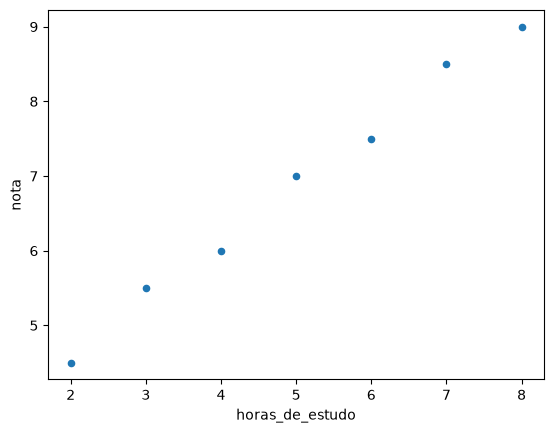

In [2]:
df.plot(kind="scatter",
        x="horas_de_estudo",
        y="nota")

### Ajuste do modelo linear

In [3]:
from sklearn.linear_model import LinearRegression
modelo = LinearRegression()
X = df[["horas_de_estudo"]] # horas de estudo é a variável preditora
y = df["nota"] # nota é a variável resposta
modelo.fit(X, y)

a = modelo.coef_ # coeficiente angualar
b = modelo.intercept_ # coeficiente linear

print(f"Coef. angular: {a}")
print(f"Coef. linear: {b}")

Coef. angular: [0.75]
Coef. linear: 3.1071428571428577


### Usando o modelo para predições

#### Plotando a reta de regressão

In [4]:
# calculando os pontos da reta de regressão
import numpy as np

x = np.array(df["horas_de_estudo"])
y_pred = a * x + b # y predito pelo modelo para cada valor de x

print("Todos os valores de y preditos pelo modelo:")
print(y_pred)

Todos os valores de y preditos pelo modelo:
[4.60714286 5.35714286 6.10714286 6.85714286 7.60714286 8.35714286
 9.10714286]


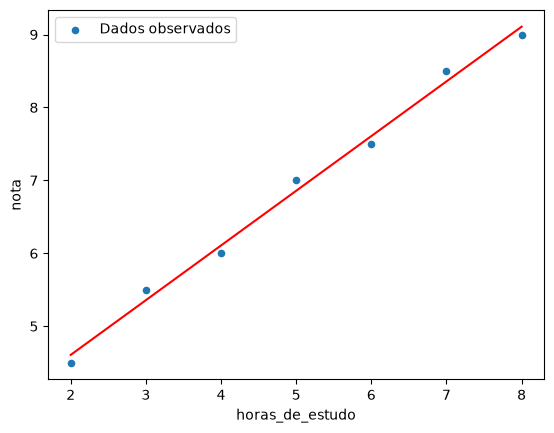

In [5]:
# plotando dados observados e a reta de regressão

import matplotlib.pyplot as plt

# plot dos dados observados
df.plot(kind="scatter",
        x="horas_de_estudo",
        y="nota",
        label="Dados observados")

# plot da reta de regressão - x=dados observados, y = y_pred (dados preditos pelo modelo)
plt.plot(
    x,
    y_pred,
    color="red"
)

### Predizendo um valor

In [6]:
# Prevendo a nota de um aluno que estudou 5.5 horas
horas_estudo_nao_observada = 5.5
nota_predita = modelo.predict(pd.DataFrame({
    "horas_de_estudo": [horas_estudo_nao_observada] # note que colocamos o valor dentro de uma lista
                                                    # isso é para manter a consistência do formato de entrada,
                                                    # que deve ser um dataframe mesmo que seja apenas um valor
}))
                                                              
nota_predita

array([7.23214286])

### Predizendo vários valores

In [7]:
# Prevendo a nota de um aluno que estudou 5.5, 6.5 e 9.0 horas
horas_estudo_nao_observadas = [5.5, 6.5, 9.0]
notas_preditas = modelo.predict(pd.DataFrame({
    "horas_de_estudo": horas_estudo_nao_observadas
}))
      
notas_preditas

array([7.23214286, 7.98214286, 9.85714286])